In [102]:
import torch
import matplotlib.pyplot as plt
import torchvision

from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchmetrics.classification import MulticlassAccuracy

In [18]:
train_data = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    download = True,
    train = True,
    target_transform = None
)

test_data = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    download = True,
    root = "data",
    train = False,
    target_transform = None
)

In [19]:
len(train_data), len(test_data)

(60000, 10000)

In [32]:
def tanh(x: torch.Tensor) -> torch.Tensor:
    result = (torch.exp(x) - torch.exp(-x) / torch.exp(x) + torch.exp(-x))
    return result

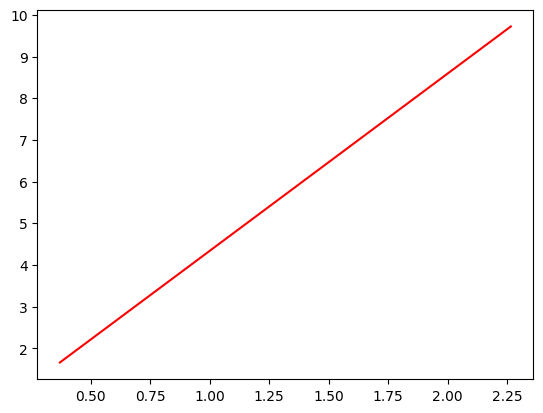

In [34]:
x = torch.randn(2)
y = tanh(x)
plt.plot(x, y, label = "Tanh Function", c="red")

In [20]:
train_data_loader = DataLoader(train_data, shuffle = True, batch_size = 64)
test_data_loader = DataLoader(test_data, shuffle = True, batch_size = 64)

In [28]:
train_classnames = train_data.classes

In [21]:
len(train_data_loader), len(test_data_loader)

(938, 157)

In [22]:
image, target = next(iter(train_data_loader))

In [38]:
image.shape, target[0], len(target.unique())

(torch.Size([64, 1, 28, 28]), tensor(6), 10)

In [35]:
28 * 28

784

Text(0.5, 1.0, 'Shirt')

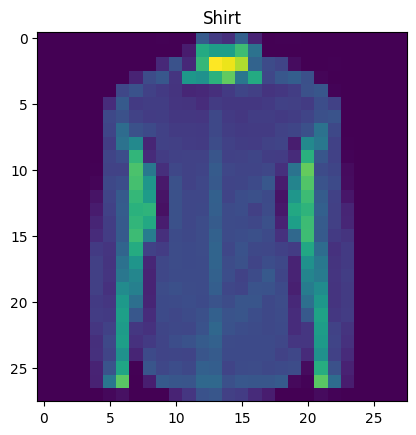

In [30]:
plt.imshow(image[0].squeeze())
plt.title(train_classnames[target[0]])

In [194]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, in_features: int = 784,
                 out_features: int = 10,
                 hidden_units: int = 128,
                 batch_unit: int = 64
        ):
        super(FashionMNISTModel, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_unit: int = batch_unit

        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.batch_unit),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.batch_unit,
                           out_features = self.batch_unit)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [195]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [196]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [197]:
model = FashionMNISTModel(out_features = 10, hidden_units = 128, batch_unit = 64).to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=64, bias=True)
  )
)

In [198]:
test_classnames = test_data.classes
torch.manual_seed(42)

model.eval()
image, target = next(iter(test_data_loader))
single_image = image[0].unsqueeze(1).to(device)

with torch.inference_mode():
    image, target = image.to(device), target.to(device)
    y_logits = model(single_image)
    y_pred = torch.argmax(y_logits, dim = 1)

# plt.imshow(y_logits.squeeze().detach().cpu())
# test_classnames[y_pred.squeeze()]
test_classnames, y_pred

(['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'],
 tensor([29], device='mps:0'))

In [199]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-5)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [200]:
from timeit import default_timer as timer

def calculate_training_time(start: float, end: float, device: torch.device = "cpu"):
    time_taken = end - start
    print(f"Time Taken : {time_taken:.3f}, on Device: {device}")
    return

In [201]:
epochs = 50
total_epochs = []
losses = []
test_losses = []
total_train_accuracy = []
total_test_accuracy = []

start = timer()

for epoch in tqdm(range(epochs)):
    running_loss = 0.0
    running_test_loss = 0.0
    running_accuracy = 0.0
    running_test_accuracy = 0.0
    accuracy_fn.reset()

    model.train()
    for idx, (image, target) in enumerate(train_data_loader):
        image, target = image.to(device), target.to(device)
        y_logits = model(image)

        loss = loss_fn(y_logits, target)
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        y_true = torch.argmax(y_logits, dim = 1)
        train_accuracy = accuracy_fn.update(target, y_true)
        running_loss += loss.item()
        # running_accuracy += train_accuracy.item()

    avg_train_loss = running_loss / len(train_data_loader)
    avg_train_accuracy = accuracy_fn.compute().item()
    losses.append(loss.item())
    # total_train_accuracy.append(train_accuracy.item())
    total_train_accuracy.append(avg_train_accuracy)

    model.eval()
    accuracy_fn.reset()
    with torch.inference_mode():
        for idx, (image, target) in enumerate(test_data_loader):
            image, target = image.to(device), target.to(device)
            test_logits = model(image)

            test_loss = loss_fn(test_logits, target)
            test_pred = torch.argmax(test_logits, dim = 1)
            test_accuracy = accuracy_fn.update(target, test_pred)

            running_test_loss += test_loss.item()
            # running_test_accuracy += test_accuracy.item()

        avg_test_loss = running_test_loss / len(test_data_loader)
        avg_test_accuracy = accuracy_fn.compute().item()
        test_losses.append(test_loss.item())
        # total_test_accuracy.append(test_accuracy.item())
        total_test_accuracy.append(avg_test_accuracy)

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Training Loss: {avg_train_loss:.5f} | Accuracy: {avg_train_accuracy:.3f}")
        print(f"Testing Loss: {avg_test_loss:.5f} | Accuracy: {avg_test_accuracy:.3f}")

end = timer()
calculate_training_time(start, end, device)

  2%|▉                                           | 1/50 [00:09<07:56,  9.73s/it]

Training Loss: 0.61227 | Accuracy: 0.792
Testing Loss: 0.49740 | Accuracy: 0.832


 12%|█████▎                                      | 6/50 [00:55<06:46,  9.24s/it]

Training Loss: 0.30008 | Accuracy: 0.889
Testing Loss: 0.36761 | Accuracy: 0.875


 22%|█████████▍                                 | 11/50 [01:42<06:10,  9.50s/it]

...

Training Loss: 0.12005 | Accuracy: 0.954
Testing Loss: 0.43890 | Accuracy: 0.891


 92%|███████████████████████████████████████▌   | 46/50 [09:28<00:54, 13.61s/it]

Training Loss: 0.11046 | Accuracy: 0.958
Testing Loss: 0.45982 | Accuracy: 0.890


100%|███████████████████████████████████████████| 50/50 [10:05<00:00, 12.12s/it]

Time Taken : 605.972, on Device: mps


('Ankle boot', 'Ankle boot')

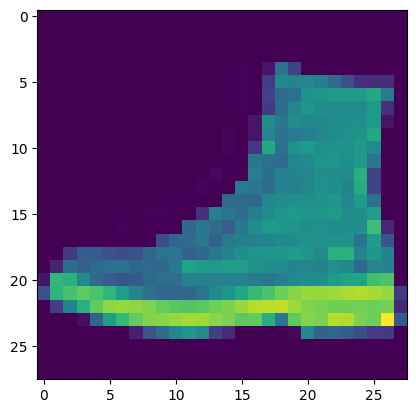

In [203]:
torch.manual_seed(42)

test_classnames = test_data.classes

image, label = next(iter(test_data_loader))
single_image = image[20].to(device)

model.eval()
with torch.inference_mode():
    y_logits = model(single_image)
    y_pred = torch.argmax(y_logits, dim = 1)

# plt.imshow(y_pred.squeeze().detach().cpu())
# y_pred.squeeze().cpu()

# plt.imshow(y_pred.squeeze().cpu())
plt.imshow(single_image.squeeze().cpu())
test_classnames[label[20]], test_classnames[y_pred]

In [129]:
len(test_data_loader)

157

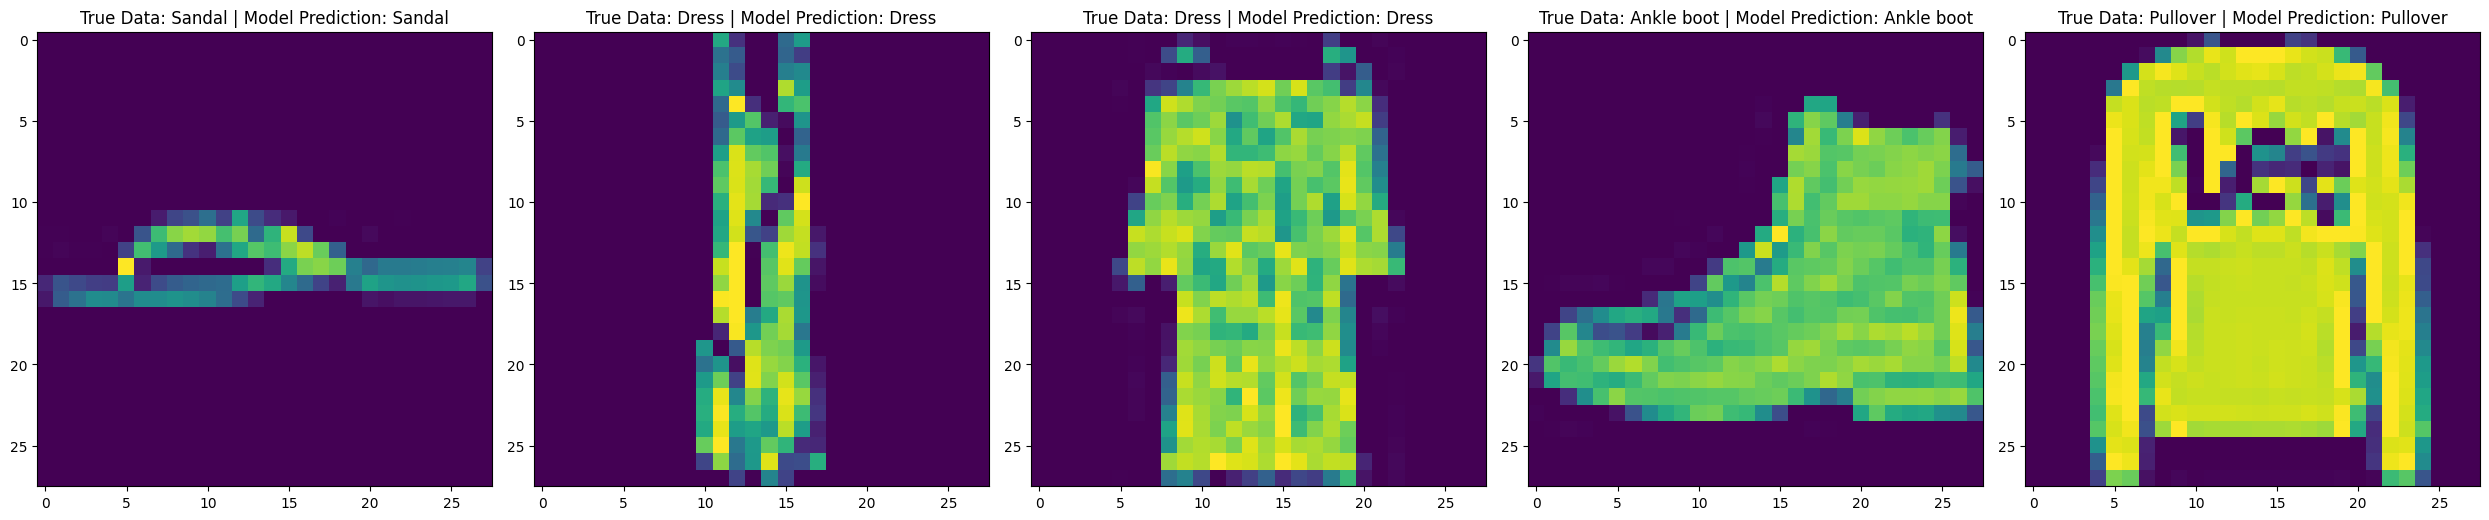

In [166]:
# torch.manual_seed(42)
# torch.mps.manual_seed(42)

model.eval()

fig = plt.figure(figsize = (25, 20))

# with torch.inference_mode():
#     for idx, image, label in enumerate(test_data_loader):
#         image, label = image.to(device), label.to(device)
#         for i in range(5):
#             randon_idx = torch.randint(0, len(test_data_loader), size = (1,))
#             y_logits = model(image[random_idx])

# for i in range(5)
with torch.inference_mode():
    for i in range(5):
    # image, label = next(iter(test_data_loader))
        rand_idx = torch.randint(1, len(test_data_loader), size = (1,)).item()
        
        image, label = test_data_loader.dataset[rand_idx]
        image = image.to(device).unsqueeze(0)
        y_logits = model(image)
        y_pred = torch.argmax(y_logits, dim = 1)
    
        plt.subplot(1, 5, i + 1)
        # plt.
        plt.title(f"True Data: {test_classnames[label]} | Model Prediction: {test_classnames[y_pred]}")
        plt.imshow(image.squeeze().cpu())

plt.tight_layout()
plt.show()

In [141]:
# image, label = test_data_loader.dataset[0]
# label

9

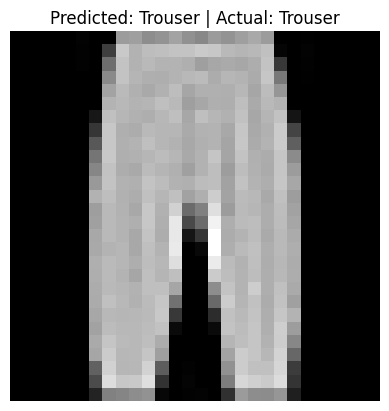

In [147]:
model.eval()

rand_idx = torch.randint(0, len(test_data_loader.dataset), size=(1,)).item()

image, label = test_data_loader.dataset[rand_idx]
image_device = image.unsqueeze(0).to(device)

with torch.inference_mode():
    y_logits = model(image_device)
    y_pred = torch.argmax(y_logits, dim=1).item()

plt.imshow(image.squeeze().cpu(), cmap="gray")
plt.title(f"Predicted: {test_classnames[y_pred]} | Actual: {test_classnames[label]}")
plt.axis("off")
plt.show()


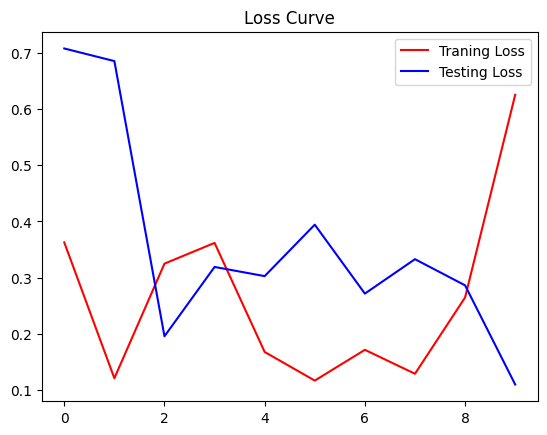

In [168]:
plt.plot(total_epochs, losses, label = "Traning Loss", c="red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c="blue")
plt.title("Loss Curve")
plt.legend()
plt.show()

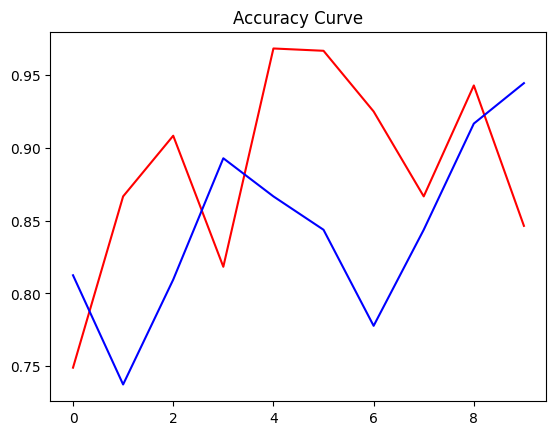

In [169]:
plt.plot(total_epochs, total_train_accuracy, label = "Training Accuracy", c="red")
plt.plot(total_epochs, total_test_accuracy, label = "Testing Accuracy", c="blue")
plt.title("Accuracy Curve")
plt.show()